In [1]:
print("hello")

hello


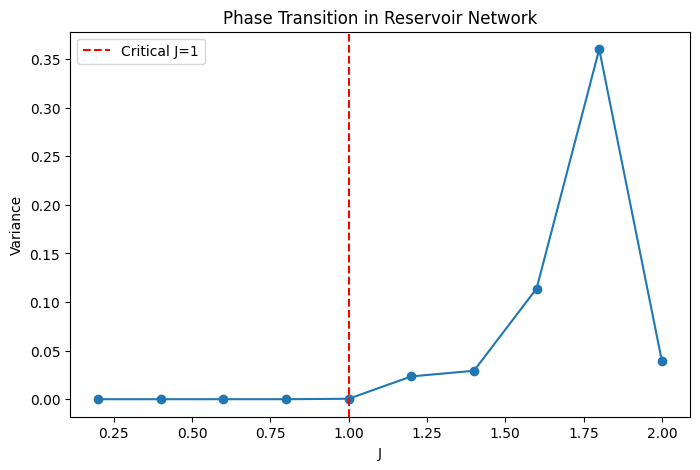

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# PARAMETERS
N = 100                # number of neurons
T = 1000               # time steps
dt = 0.1               # step size
J_values = np.linspace(0.2, 2.0, 10)  # range of J

def simulate(J):
    # Weight matrix W ~ N(0, J^2 / N)
    W = np.random.normal(0, J/np.sqrt(N), (N, N))
    
    # Initial condition (small random values)
    r = np.random.uniform(-0.1, 0.1, N)
    
    # Store trajectory
    r_history = []
    
    for t in range(T):
        r = r + dt * (-r + np.tanh(W @ r))
        r_history.append(r.copy())
    
    r_history = np.array(r_history)
    
    # Compute variance over time, then average across neurons
    variance = np.mean(np.var(r_history, axis=0))
    
    return variance

# Run simulation for different J
variances = []

for J in J_values:
    var = simulate(J)
    variances.append(var)

# Plot results
plt.figure(figsize=(8,5))
plt.plot(J_values, variances, marker='o')
plt.axvline(x=1, color='red', linestyle='--', label='Critical J=1')
plt.xlabel("J")
plt.ylabel("Variance")
plt.title("Phase Transition in Reservoir Network")
plt.legend()
plt.show()

Average variance over neurons (Gaussian): 0.229885590144797


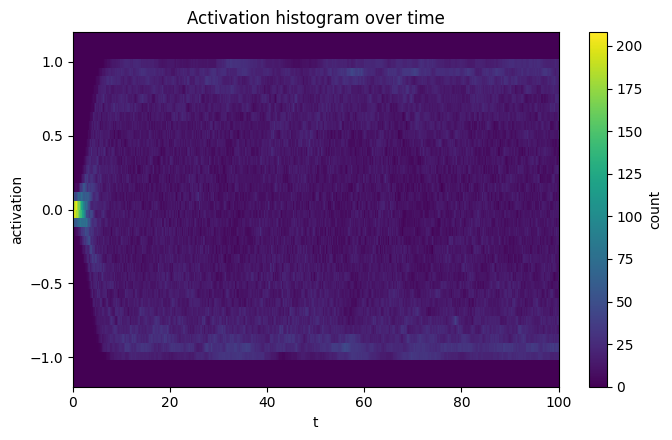

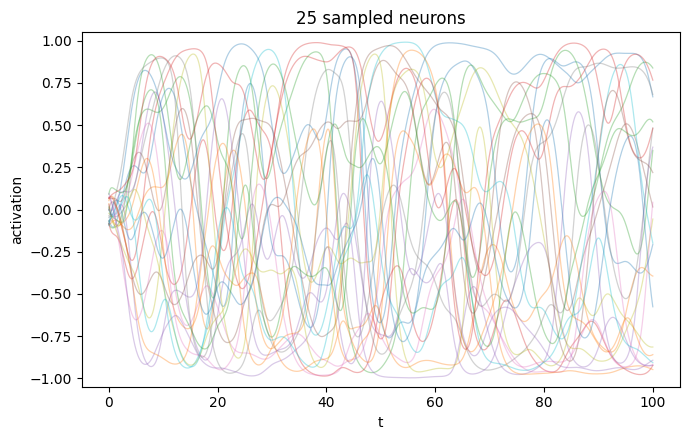

Average variance over neurons (Erdos-Renyi): 3.071984147001533e-11


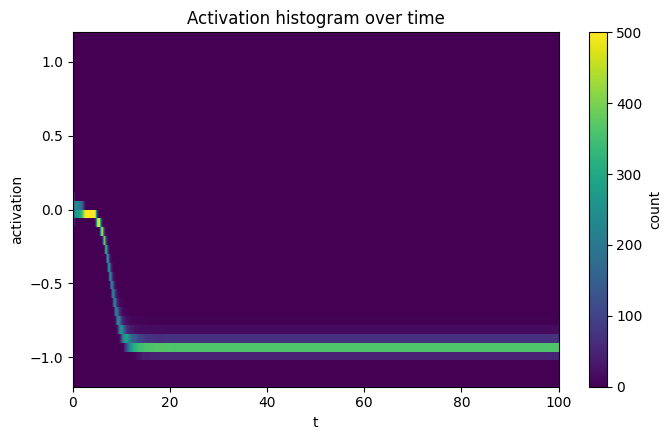

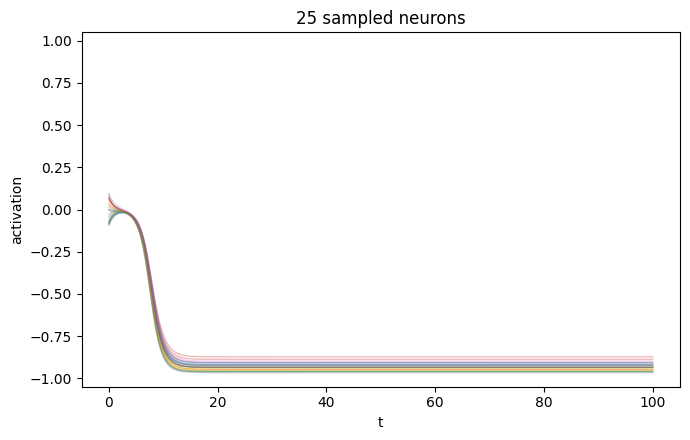

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def init_state(N, kind="uniform_small", seed=None):
    rng = np.random.default_rng(seed)
    if kind == "uniform_small":
        return rng.uniform(-0.1, 0.1, size=N)
    elif kind == "normal_small":
        return rng.normal(0, 0.1, size=N)
    else:
        raise ValueError(f"Unknown state initializer: {kind}")


def init_matrix(N, J, kind="gaussian", seed=None, zero_diag=True):
    rng = np.random.default_rng(seed)

    if kind == "gaussian":
        W = rng.normal(0, J / np.sqrt(N), size=(N, N))
    elif kind == "fully_connected":
        W = np.full((N, N), J / N)
    else:
        raise ValueError(f"Unknown matrix initializer: {kind}")

    if zero_diag:
        np.fill_diagonal(W, 0.0)

    return W


def init_matrix_erdos_renyi(N, J, p, seed=None, zero_diag=True):
    rng = np.random.default_rng(seed)

    A = (rng.random((N, N)) < p).astype(float)

    if zero_diag:
        np.fill_diagonal(A, 0.0)

    k = p * N
    W = (J / k) * A

    return W


def euler_step(x, W, dt):
    return x + dt * (-x + np.tanh(W @ x))


def simulate_trajectory(x0, W, dt, t_final):
    n_steps = int(t_final / dt)
    X = np.zeros((n_steps + 1, len(x0)))
    X[0] = x0

    x = x0.copy()
    for t in range(1, n_steps + 1):
        x = euler_step(x, W, dt)
        X[t] = x

    return X


def mean_variance_over_neurons(X, discard_fraction=0.2):
    start = int(discard_fraction * X.shape[0])
    return np.mean(np.var(X[start:], axis=0))


def plot_random_neurons(X, dt, n_plot=25, seed=None):
    rng = np.random.default_rng(seed)
    indices = rng.choice(X.shape[1], size=min(n_plot, X.shape[1]), replace=False)
    times = np.arange(X.shape[0]) * dt

    plt.figure(figsize=(7, 4.5))
    for i in indices:
        plt.plot(times, X[:, i], alpha=0.35, linewidth=0.9)

    plt.xlabel("t")
    plt.ylabel("activation")
    plt.title(f"{len(indices)} sampled neurons")
    plt.ylim(-1.05, 1.05)
    plt.tight_layout()
    plt.show()


def plot_activation_histogram_over_time(X, dt, bins=40, activation_range=(-1.2, 1.2)):
    n_times = X.shape[0]
    bin_edges = np.linspace(activation_range[0], activation_range[1], bins + 1)
    hist_matrix = np.zeros((bins, n_times))

    for t in range(n_times):
        counts, _ = np.histogram(X[t, :], bins=bin_edges)
        hist_matrix[:, t] = counts

    times = np.arange(n_times) * dt

    plt.figure(figsize=(7, 4.5))
    plt.imshow(
        hist_matrix,
        aspect="auto",
        origin="lower",
        extent=[times[0], times[-1], activation_range[0], activation_range[1]],
        interpolation="nearest",
        cmap="viridis"
    )
    plt.colorbar(label="count")
    plt.xlabel("t")
    plt.ylabel("activation")
    plt.title("Activation histogram over time")
    plt.ylim(activation_range)
    plt.tight_layout()
    plt.show()

# Gaussian random network

N = 500
J = 1.8
dt = 0.05
t_final = 100.0

x0 = init_state(N, kind="uniform_small", seed=1)
W = init_matrix(N, J, kind="gaussian", seed=2, zero_diag=True)
X = simulate_trajectory(x0, W, dt, t_final)

stat = mean_variance_over_neurons(X, discard_fraction=0.2)
print("Average variance over neurons (Gaussian):", stat)

plot_activation_histogram_over_time(X, dt=dt, bins=40, activation_range=(-1.2, 1.2))
plot_random_neurons(X, dt=dt, n_plot=25, seed=3)

# Erdős–Rényi network

N = 500
J = 1.8
p = 0.1
dt = 0.05
t_final = 100.0

x0_er = init_state(N, kind="uniform_small", seed=1)
W_er = init_matrix_erdos_renyi(N, J, p, seed=2, zero_diag=True)
X_er = simulate_trajectory(x0_er, W_er, dt, t_final)

stat_er = mean_variance_over_neurons(X_er, discard_fraction=0.2)
print("Average variance over neurons (Erdos-Renyi):", stat_er)

plot_activation_histogram_over_time(X_er, dt=dt, bins=40, activation_range=(-1.2, 1.2))
plot_random_neurons(X_er, dt=dt, n_plot=25, seed=3)

# The second plot shows the time evolution of a sample of neuron activities. For J = 1.8 > 1, 
# the trajectories do not converge to a stable value but instead continue to fluctuate over time. 
# The system is in a dynamically active regime, where interactions between neurons generate 
# persistent and complex behavior rather than convergence to equilibrium.

# In the Erdős–Rényi network, the neuron trajectories rapidly converge to a stable fixed point, 
# as all activities approach approximately −1. This contrasts with the Gaussian case, where persistent 
# fluctuations were observed for the same value of J.